In [18]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
mean_absolute_error,
mean_squared_error,
r2_score
)

In [19]:
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

In [20]:
sns.set_theme(
style="whitegrid",
palette="Set2"
)

plt.rcParams["figure.figsize"] = (12,6)

plt.rcParams["figure.dpi"] = 120

In [21]:
df = pd.read_csv(
    "../data/final/ml_dataset.csv"
)

In [22]:
df.columns = (
df.columns
.str.strip()
.str.lower()
)

In [23]:
df.head()

,id,week_of_outbreak,state_ut,district,disease,cases,deaths,day,month,year,...,temp_change,precipitation_change,lai_change,spike_ratio,acceleration,growth_rate,outbreak_flag,outbreak_frequency_12m,log_cases,outbreak
0,837,23rd week,Andaman and Nicobar Islands,Andaman,Acute Diarrhoeal Disease,8.0,1,6,6,2019,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0,0.0,2.197225,0
1,1192,41st week,Andaman and Nicobar Islands,Andaman,Acute Diarrhoeal Disease,30.0,1,9,10,2019,...,-2.813333,-0.622747,9.0,0.0,0.0,0.0,0,0.0,3.433987,0
2,6193,51st week,Andaman and Nicobar Islands,North and Middle Andaman,Acute Diarrhoeal Disease,86.0,1,16,12,2013,...,0.000000,0.000000,0.0,0.0,0.0,0.0,1,0.0,4.465908,1
3,6526,25th week,Andhra Pradesh,Anantapur,Acute Diarrhoeal Disease,23.0,0,26,6,2011,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0,0.0,3.178054,0
4,7342,25th week,Andhra Pradesh,Anantapur,Acute Diarrhoeal Disease,23.0,0,26,6,2011,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0,0.0,3.178054,0


In [24]:
#DATE PROCESSING
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

In [25]:
#TARGETS

TARGET_REGRESSION = "log_cases"
TARGET_CLASSIFICATION = "outbreak"

In [26]:
# REMOVE LEAKAGE + KEEP ONLY NUMERIC FEATURES

REMOVE_COLS = [

    "cases",
    "log_cases",
    "outbreak",
    "date",
    "id"
]
# Initial feature selection
FEATURES = [
    col
    for col in df.columns
    if col not in REMOVE_COLS
]
FEATURES = [
    col
    for col in FEATURES
    if pd.api.types.is_numeric_dtype(df[col])
]

print("TOTAL FEATURES:")
print(len(FEATURES))
print(FEATURES)

print("FEATURE MATRIX SHAPE")
print(X.shape)

TOTAL FEATURES:
29
['deaths', 'day', 'month', 'year', 'latitude', 'longitude', 'precipitation', 'lai', 'temp', 'death_rate', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'roll_3_mean', 'roll_6_mean', 'roll_3_std', 'roll_6_std', 'month_sin', 'month_cos', 'temp_change', 'precipitation_change', 'lai_change', 'spike_ratio', 'acceleration', 'growth_rate', 'outbreak_flag', 'outbreak_frequency_12m']
FEATURE MATRIX SHAPE
(8984, 29)


In [27]:
#MODEL DATA

X = df[FEATURES]
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)
X = X.fillna(0)
y = df[TARGET_REGRESSION]
print(
    X.select_dtypes(include="object").columns
)

Index([], dtype='object')


In [28]:
#CHECK MISSING VALUES

print( X.isnull().sum().sort_values(ascending=False).head())

deaths           0
roll_3_mean      0
outbreak_flag    0
growth_rate      0
acceleration     0
dtype: int64


In [29]:
#TIME SERIES SPLIT

tscv = TimeSeriesSplit(n_splits=5)

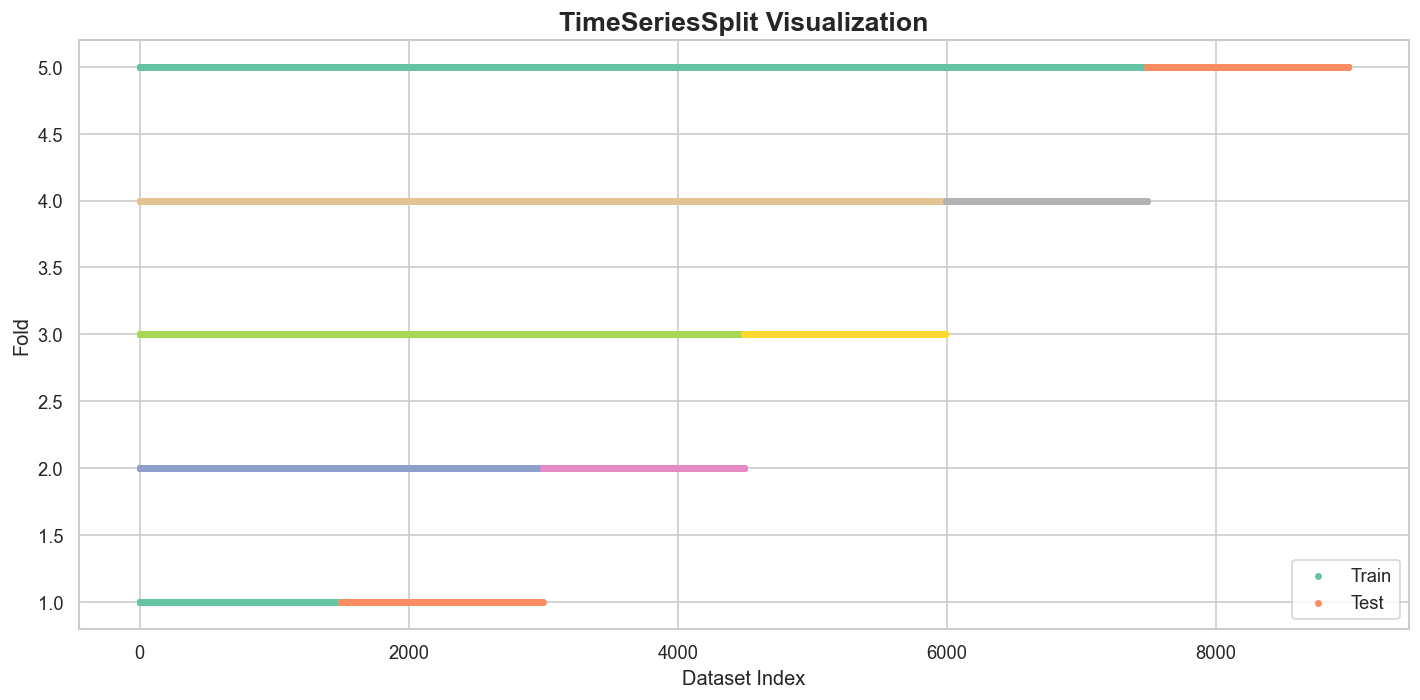

In [30]:
# VISUALIZE SPLITS

plt.figure(figsize=(12, 6))

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    plt.scatter(
        train_idx,
        [fold + 1] * len(train_idx),
        label="Train" if fold == 0 else "",
        s=10
    )
    plt.scatter(
        test_idx,
        [fold + 1] * len(test_idx),
        label="Test" if fold == 0 else "",
        s=10
    )
plt.title(
    "TimeSeriesSplit Visualization",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Dataset Index")
plt.ylabel("Fold")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../reports/timeseries_split.png",
    bbox_inches="tight"
)
plt.show()

In [31]:
#BASELINE MODEL

model = LinearRegression()

In [32]:
#TRAINING LOOP
fold_results = []

for fold, (train_idx, test_idx) in enumerate(
    tscv.split(X),
    start=1
):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    preds = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, preds)

    rmse = np.sqrt(
        mean_squared_error(y_test, preds)
    )

    r2 = r2_score(y_test, preds)

    # Store results
    fold_results.append({
        "fold": fold,
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    })

    # Print fold metrics
    print("=" * 50)

    print(f"FOLD {fold}")

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")

FOLD 1
MAE  : 0.4885
RMSE : 0.8929
R2   : 0.0871
FOLD 2
MAE  : 0.3970
RMSE : 0.5220
R2   : 0.6713
FOLD 3
MAE  : 0.4872
RMSE : 0.9138
R2   : 0.3235
FOLD 4
MAE  : 0.4211
RMSE : 0.5513
R2   : 0.7265
FOLD 5
MAE  : 0.4381
RMSE : 0.7198
R2   : 0.5371


In [33]:
#RESULTS DATAFRAME

results_df = pd.DataFrame(
fold_results
)
results_df.style.background_gradient(cmap="Blues")

,fold,mae,rmse,r2
0,1,0.488545,0.892896,0.087052
1,2,0.396991,0.522003,0.671309
2,3,0.487189,0.913752,0.323486
3,4,0.421101,0.551317,0.726516
4,5,0.438059,0.719834,0.537088


In [34]:
#AVERAGE METRICS

avg_mae = results_df["mae"].mean()
avg_rmse = results_df["rmse"].mean()
avg_r2 = results_df["r2"].mean()

print("BASELINE MODEL PERFORMANCE")

print(f"Average MAE : {avg_mae:.4f}")
print(f"Average RMSE : {avg_rmse:.4f}")
print(f"Average R2 : {avg_r2:.4f}")

BASELINE MODEL PERFORMANCE
Average MAE : 0.4464
Average RMSE : 0.7200
Average R2 : 0.4691


In [35]:
results_df.to_csv(
    "../reports/baseline_metrics.csv",
    index=False
)

print("✅ Baseline Metrics Saved")

✅ Baseline Metrics Saved


In [36]:
#FEATURE IMPORTANCE
importance_df = pd.DataFrame({
"feature": FEATURES,
"coefficient": model.coef_
})

importance_df["abs_coef"] = (
    importance_df["coefficient"].abs()
)

importance_df = (
importance_df
.sort_values(
by="coefficient",
ascending=False
))


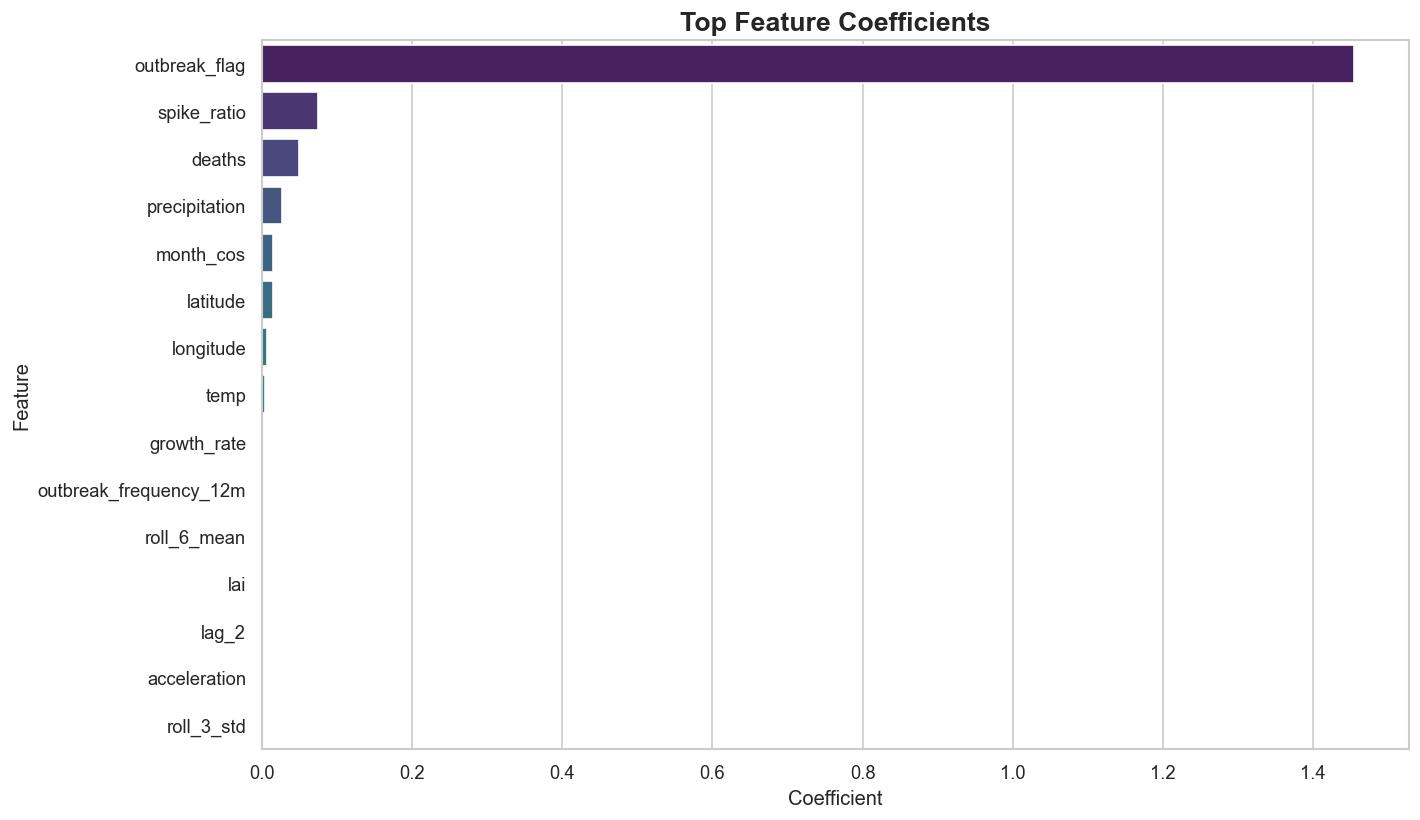

In [37]:
#TOP FEATURES

top_features = (
importance_df
.head(15)
)
plt.figure(figsize=(12,7))
sns.barplot(
data=top_features,
x="coefficient",
y="feature",
palette="viridis"
)

plt.title(
"Top Feature Coefficients",
fontsize=16,
fontweight="bold")

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(
    "../reports/feature_Coefficients.png",
    bbox_inches="tight"
)
plt.show()

In [38]:
#SAVE FEATURE IMPORTANCE
importance_df.to_csv(
"../reports/baseline_feature_importance.csv",
index=False
)

print("✅ Feature Importance Saved")

✅ Feature Importance Saved


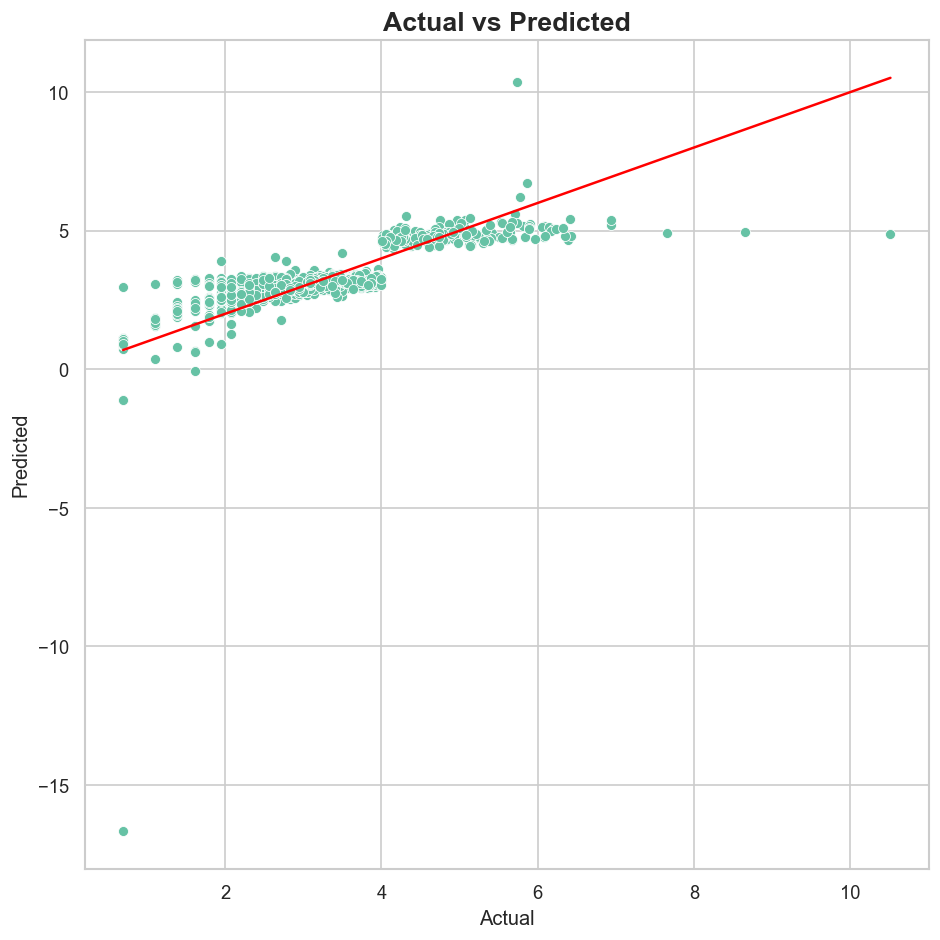

In [39]:
#PREDICTION VS ACTUAL

plt.figure(figsize=(8,8))
sns.scatterplot(
x=y_test,
y=preds
)

plt.plot(
[y_test.min(), y_test.max()],
[y_test.min(), y_test.max()],
color="red"
)

plt.title(
"Actual vs Predicted",
fontsize=16,
fontweight="bold"
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.savefig(
    "../reports/actualVSpredicted.png",
    bbox_inches="tight"
)
plt.show()

In [40]:
#SAVE EXPERIMENT

import os
os.makedirs(
"../experiments/exp_01_baseline",
exist_ok=True
)

results_df.to_csv(
"../experiments/exp_01_baseline/fold_results.csv",
index=False
)

importance_df.to_csv(
"../experiments/exp_01_baseline/feature_importance.csv",
index=False
)

print("✅ Experiment Saved")

✅ Experiment Saved


In [41]:
#FINAL SUMMARY
summary_df = pd.DataFrame({
"Metric": [
    "Average MAE",
    "Average RMSE",
    "Average R2",
    "Total Features",
    "Total Rows"
],

"Value": [
    round(avg_mae, 4),
    round(avg_rmse, 4),
    round(avg_r2, 4),
    len(FEATURES),
    len(df)
]
})

summary_df.style.background_gradient(cmap="Blues").hide(axis="index")

Metric,Value
Average MAE,0.446400
Average RMSE,0.720000
Average R2,0.469100
Total Features,29.000000
Total Rows,8984.000000


In [117]:
if avg_r2 < 0:
    print("⚠️ Model performs worse than baseline mean prediction")

elif avg_r2 < 0.3:
    print("⚠️ Weak predictive performance")

elif avg_r2 < 0.6:
    print("✅ Moderate predictive performance")

else:
    print("✅ Strong predictive performance")

✅ Moderate predictive performance
